**Esplorazione del dataset sui progetti di Informatica Umanistica in Spagna**

Fonte: https://zenodo.org/records/3893546 

Licenza: CC Attribution 4.0

**NOTE:** la fonte presenta una sorta di database che mappa progetti, istituzioni, finanziatori, ecc... tuttavia i dati qui esplorati provengono esclusivamente dal file ***mapeo_proyectos.csv*** presente nella cartella ***data***

In [22]:
import pandas as pd

In [ ]:
dataset = "../dataset/1998_2022_spagna/spagna.csv"
dh = pd.read_csv(dataset)

dh = dh.drop_duplicates() #elimino eventuali duplicati

dh.info()

<class 'pandas.DataFrame'>
Index: 371 entries, 0 to 489
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID proyecto                     371 non-null    int64  
 1   Título                          371 non-null    str    
 2   Código proyecto                 328 non-null    str    
 3   Área de procedencia/disciplina  371 non-null    str    
 4   Temas de investigación          364 non-null    str    
 5   Programa                        222 non-null    str    
 6   Subprograma                     204 non-null    str    
 7   Palabra clave AEI               217 non-null    str    
 8   Temporalización (inicio)        370 non-null    float64
 9   Temporalización (fin)           370 non-null    float64
 10  Convocatoria                    334 non-null    str    
 11  Convocatoria (año)              225 non-null    float64
 12  Años                            223 non-null    floa

In [24]:
dh.describe()

,ID proyecto,Temporalización (inicio),Temporalización (fin),Convocatoria (año),Años,Financiación,Nº de IPs
count,371.000000,370.000000,370.000000,225.000000,223.000000,3.410000e+02,329.000000
mean,1854.865229,2013.040541,2014.870270,2012.062222,2.923767,6.383619e+04,1.097264
std,685.406017,5.016610,5.174927,4.446673,0.683473,1.604296e+05,0.296769
min,141.000000,1993.000000,1995.000000,2003.000000,1.000000,0.000000e+00,1.000000
25%,1450.000000,2010.000000,2012.000000,2009.000000,3.000000,2.420000e+04,1.000000
50%,2229.000000,2014.000000,2016.000000,2012.000000,3.000000,4.235000e+04,1.000000
75%,2328.500000,2017.000000,2019.000000,2016.000000,3.000000,6.800000e+04,1.000000
max,2577.000000,2019.000000,2023.000000,2018.000000,5.000000,2.300000e+06,2.000000


Ecco la struttura del dataset:

In [25]:
dh.head()

,ID proyecto,Título,Código proyecto,Área de procedencia/disciplina,Temas de investigación,Programa,Subprograma,Palabra clave AEI,Temporalización (inicio),Temporalización (fin),...,Entidad financiadora,Página web y redes sociales,Fuente de información,Nº de IPs,Género IP,CCAA,Organismo,Centro,Estado,Última actualización
0,1348,Actualización y ampliación del Laboratorio de...,NaN,Arqueología,Análisis de imágenes | Artes visuales,NaN,NaN,NaN,1995.0,1995.0,...,Consejo Superior de Investigaciones Científica...,NaN,Congresos HDH,1.0,Masculino,MADRID,AGENCIA ESTATAL CONSEJO SUPERIOR DE INVESTIGAC...,INSTITUTO DE HISTORIA (IH),Listo,29 Dec 2019
1,1346,Aplicaciones del proceso digital de imagen al...,PB95 0227,Arqueología,Análisis de imágenes | Artes visuales,NaN,NaN,NaN,1996.0,1996.0,...,Dirección General de Investigación Científica ...,NaN,Congresos HDH,1.0,Masculino,MADRID,AGENCIA ESTATAL CONSEJO SUPERIOR DE INVESTIGAC...,INSTITUTO DE HISTORIA (IH),Listo,29 Dec 2019
2,1357,BITE II: Bibliografía temática de la Historio...,URJC-CM-2006-CSH-0390,Lingüística y lenguas,Bases de datos,NaN,NaN,NaN,2007.0,2007.0,...,Comunidad de Madrid | Universidad Rey Juan Car...,NaN,Congresos HDH,NaN,Masculino,MADRID,UNIVERSIDAD REY JUAN CARLOS,NaN,Listo,07 Jan 2020
6,141,"eLITE-CM, Edición literaria electrónica",H2015/HUM-3426,Filología,Estudios literarios digitales,NaN,NaN,NaN,2015.0,2018.0,...,Comunidad de Madrid,https://www.ucm.es/edicionliterariaelectronica...,Fuente propia,1.0,Femenino,MADRID,UNIVERSIDAD COMPLUTENSE DE MADRID,DPTO. FILOLOGIA ESPAÑOLA II (LITERATURA ESPAÑOLA),Listo,01 Mar 2020
18,1345,Modelos numéricos para la Arqueología: aplica...,PB98 0652,Arqueología,Arqueología del paisaje | Artes visuales,NaN,NaN,NaN,2000.0,2000.0,...,Dirección General de Investigación Científica ...,NaN,Congresos HDH,1.0,Masculino,MADRID,AGENCIA ESTATAL CONSEJO SUPERIOR DE INVESTIGAC...,INSTITUTO DE HISTORIA (IH),Listo,29 Dec 2019


**Pulizia del dataset**

In [28]:
#Elimino tutte le colonne "inutili"
dh.drop(columns = ["ID proyecto","Código proyecto", "Programa","Subprograma","Palabra clave AEI","Temporalización (inicio)", "Entidad financiadora", "Convocatoria","Convocatoria (año)","Años","Financiación","Página web y redes sociales","Fuente de información","Nº de IPs","Género IP","CCAA","Centro","Estado","Última actualización"], inplace = True)

dh.rename(columns = {
    "Título" : "progetto",
    "Área de procedencia/disciplina": "area/disciplina",
    "Temas de investigación" : "strumento DH",
    "Temporalización (fin)" : "anno",
    "Organismo" : "istituzione",
    }, inplace = True)

dh["anno"] = dh["anno"].astype(str).str[:4]

dh = dh.reindex(columns = ["progetto", "istituzione", "anno", "area/disciplina", "strumento DH"])

Uno snapshot del dataset "pulito"

In [29]:
dh.tail()

,progetto,istituzione,anno,area/disciplina,strumento DH
484,UTILIZACION Y OCUPACION DE LAS ZONAS HUMEDAS E...,UNIVERSIDAD DE GRANADA,2018,Historia,SIG y análisis geoespacial
485,VARIACION LINGUISTICA Y COMUNICACION INTERCULT...,UNIVERSIDAD AUTONOMA DE MADRID,2011,Filología,Lingüística y lenguas | Lingüística computacional
486,VESTIGIUM: CIENTIFICOS Y HUMANISTAS VALENCIANO...,UNIVERSITAT POLITÈCNICA DE VALÈNCIA,2012,Sociología,Web semántica
487,Voces y silencios: discursos culturales en la ...,UNIVERSIDAD DE CORDOBA,2020,Filología,"Archivos digitales, repositorios y preservación"
489,Web semántica y Patrimonio cultural. Los paisa...,UNIVERSIDAD DE ALICANTE,2021,Historia | Historia del Arte,Web semántica | Aplicaciones y diseño para móv...


Domanda: **Quali sono le istituzioni più attive in progetti di InfoUma in Spagna?**

*I primi 10 posti*

[Text(3, 0, '8'),
 Text(3, 0, '9'),
 Text(3, 0, '9'),
 Text(3, 0, '10'),
 Text(3, 0, '10'),
 Text(3, 0, '10'),
 Text(3, 0, '14'),
 Text(3, 0, '15'),
 Text(3, 0, '15'),
 Text(3, 0, '15'),
 Text(3, 0, '21'),
 Text(3, 0, '23'),
 Text(3, 0, '25'),
 Text(3, 0, '30'),
 Text(3, 0, '33')]

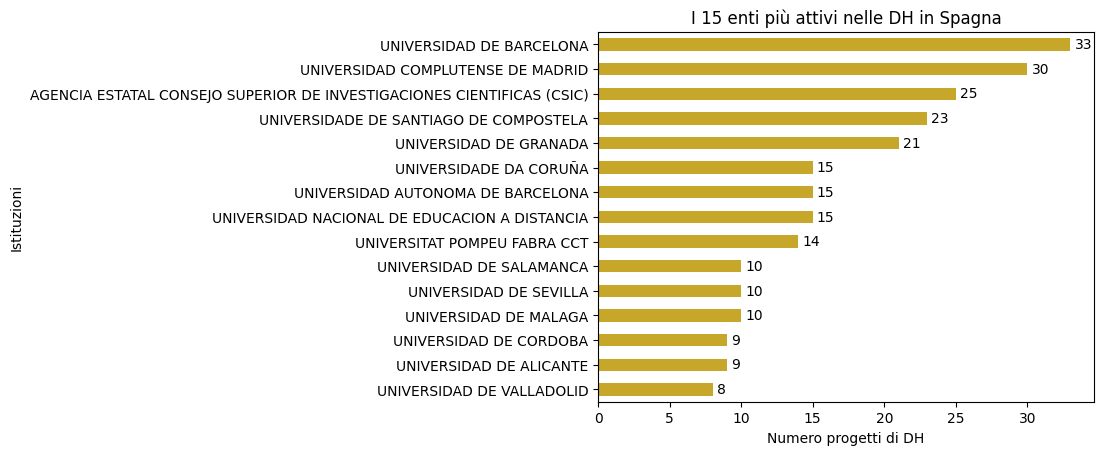

In [32]:
top_istituzioni = dh.groupby("istituzione").count()["progetto"].sort_values(ascending=False)
top_15_istituzioni = top_istituzioni[:15].sort_values(ascending=True)

ax = top_15_istituzioni.plot(
    kind = "barh",
    x = "istituzione",
    xlabel = "Numero progetti di DH",
    ylabel = "Istituzioni",
    color = "#c6a72a",
    title = "I 15 enti più attivi nelle DH in Spagna",
    # grid = True
)

ax.bar_label(ax.containers[0], padding=3)

**Serie storica dei progetti di DH in Spagna (1995 - 2022)**

In [ ]:
conteggi_anno = dh.groupby("anno")["progetto"].count()[:-1] #Taglio l'ultima colonna che contiene i valori senza anno

if not isinstance(conteggi_anno, pd.DataFrame):
    conteggi_anno = conteggi_anno.to_frame().reset_index()

conteggi_anno.rename(columns = {"progetto":"progetti"}, inplace = True)

fill = pd.DataFrame({
    "anno" : ["1998", "2003"],
    "progetti" : [0, 0]
})

conteggi_anno = pd.concat([conteggi_anno, fill], ignore_index = True)
conteggi_anno["anno"] = pd.to_numeric(conteggi_anno["anno"])
conteggi_anno = conteggi_anno.sort_values(by = "anno").reset_index(drop = True)


print(conteggi_anno)

    anno  progetti
0   1995         2
1   1996         1
2   1997         1
3   1998         0
4   1999         2
5   2000         2
6   2001         1
7   2002         1
8   2003         0
9   2004         1
10  2005         1
11  2006        11
12  2007         6
13  2008        13
14  2009        19
15  2010        10
16  2011        20
17  2012        23
18  2013        10
19  2014        29
20  2015        22
21  2016        22
22  2017        30
23  2018        41
24  2019        32
25  2020        25
26  2021        35
27  2022         9


[Text(0, 3, '2'),
 Text(0, 3, '1'),
 Text(0, 3, '1'),
 Text(0, 3, '0'),
 Text(0, 3, '2'),
 Text(0, 3, '2'),
 Text(0, 3, '1'),
 Text(0, 3, '1'),
 Text(0, 3, '0'),
 Text(0, 3, '1'),
 Text(0, 3, '1'),
 Text(0, 3, '11'),
 Text(0, 3, '6'),
 Text(0, 3, '13'),
 Text(0, 3, '19'),
 Text(0, 3, '10'),
 Text(0, 3, '20'),
 Text(0, 3, '23'),
 Text(0, 3, '10'),
 Text(0, 3, '29'),
 Text(0, 3, '22'),
 Text(0, 3, '22'),
 Text(0, 3, '30'),
 Text(0, 3, '41'),
 Text(0, 3, '32'),
 Text(0, 3, '25'),
 Text(0, 3, '35'),
 Text(0, 3, '9')]

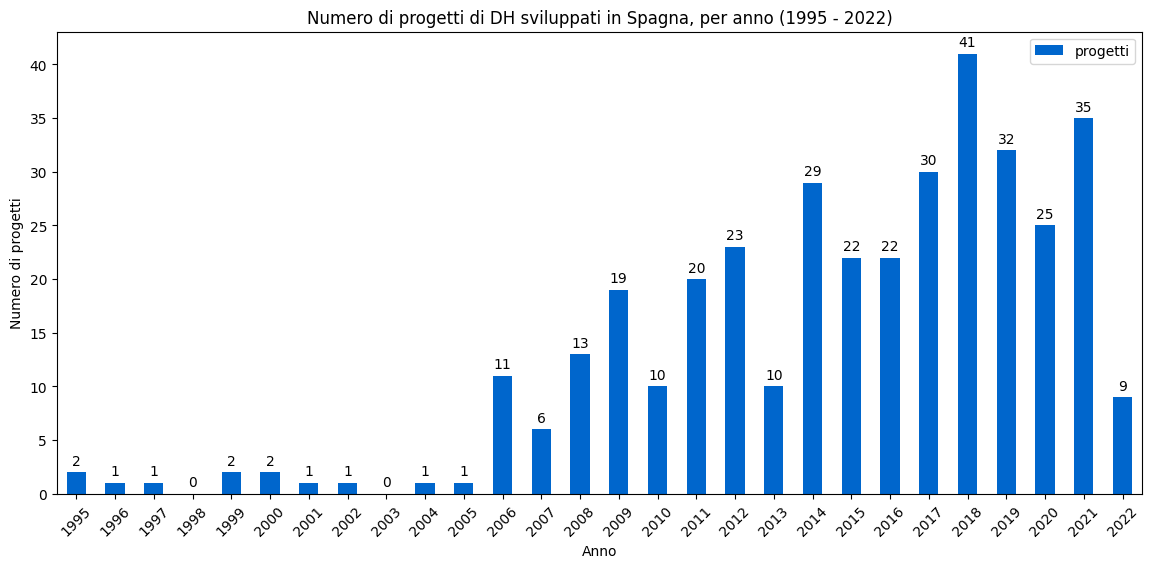

In [33]:
ax = conteggi_anno.plot(
    kind = "bar",
    # grid = True,
    color = "#0066cc",
    x = "anno",
    y = "progetti",
    xlabel="Anno",
    ylabel="Numero di progetti",
    title = "Numero di progetti di DH sviluppati in Spagna, per anno (1995 - 2022)",
    figsize = (14,6),
    rot = 45
)


ax.bar_label(ax.containers[0], padding=3)

**I progetti di DH sviluppati dalle Università di Barcellona**

In [ ]:
#Filtro con espressioni regolari
filtro = dh["istituzione"].str.contains(r"BARCELONA", regex = True, na = False) #in questo dataset i nomi delle università/istituzioni sono tutti in maiuscolo
barcelona = dh[filtro]
barcelona

,progetto,istituzione,anno,area/disciplina,strumento DH
50,Atapuerca-Evolución. Videojuegos Educativos,UNIVERSIDAD DE BARCELONA,2018,Arqueología | Ciencias de la educación,Videojuegos | Aplicaciones y diseño para móvil...
56,Banco de datos diacrónico e hispánico: morfolo...,UNIVERSIDAD AUTONOMA DE BARCELONA,2008,Filología,Lingüística y lenguas | Bases de datos
112,BITECA Y SU CONTEXTO LITERARIO (OCCITANO Y LAT...,UNIVERSIDAD DE BARCELONA,2017,Filología,Bases de datos | Estudios literarios digitales
114,Búsqueda Semántica de ImágeNes y Texto en HEme...,UNIVERSIDAD DE BARCELONA,2019,Biblioteconomía y documentación,"Archivos digitales, repositorios y preservació..."
117,CARAS OCULTAS DEL DESARROLLO ECONOMICO: ENERGI...,UNIVERSIDAD DE BARCELONA,2009,Geografía,SIG y análisis geoespacial
118,CARAS OCULTAS DEL DESARROLLO ECONOMICO: ENERGI...,UNIVERSIDAD DE BARCELONA,2009,Geografía,SIG y análisis geoespacial
124,CBA-2008: WORKSHOP ON CORPUS-BASED APPROACHES ...,UNIVERSIDAD DE BARCELONA,2009,Filología,Actividades de corpus | Lingüística computacional
127,CIENCIA VERNACULA EN LA CORONA DE ARAGON Y EN ...,UNIVERSIDAD DE BARCELONA,2018,Filología,Patrimonio digital
129,Compartiendo el dolor y el duelo online: la im...,UNIVERSIDAD DE BARCELONA,2017,Artes visuales,Análisis de imágenes
134,COMUNICACION INDIGENA Y PATRIMONIO CULTURAL EN...,UNIVERSIDAD DE BARCELONA,2021,Historia,Ciencias y Técnicas Historiográficas
